In [14]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent

sys.path.insert(
    0,
    str(PROJECT_ROOT),
)

from src.risk.dashboard_metrics import (
    build_dashboard_metrics,
)

metrics = (
    build_dashboard_metrics()
)

metrics

{'var_99': 92151.25490633634,
 'es_99': 139652.44233582474,
 'worst_daily_pnl': -284663.69509490486,
 'worst_stress_pnl': -434787.92285174126,
 'breaches': 2,
 'warnings': 2}

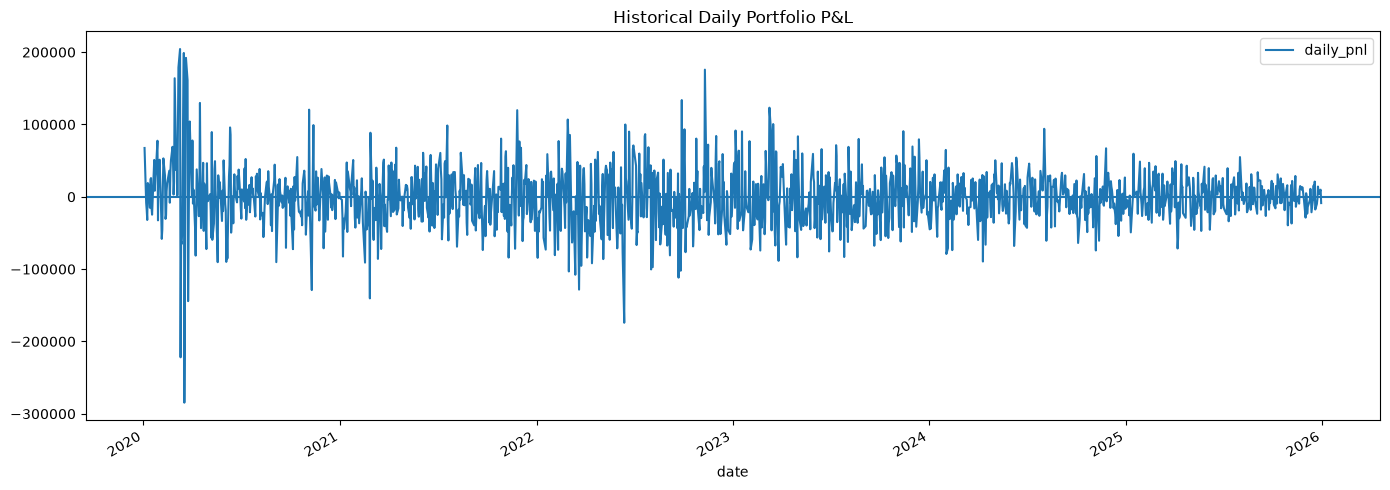

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

daily_pnl = pd.read_csv(
    PROJECT_ROOT
    / "reports"
    / "daily_pnl.csv",
    parse_dates=["date"],
)

daily_pnl.plot(
    x="date",
    y="daily_pnl",
    figsize=(14, 5),
    title="Historical Daily Portfolio P&L",
)

plt.axhline(0)
plt.tight_layout()
plt.show()

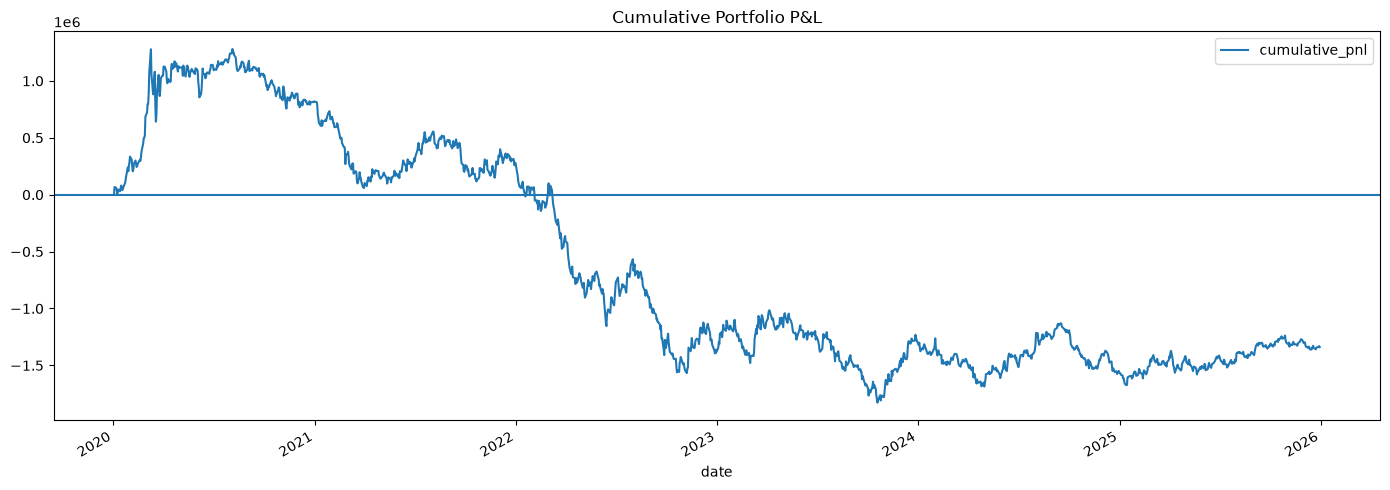

In [16]:
daily_pnl[
    "cumulative_pnl"
] = daily_pnl[
    "daily_pnl"
].fillna(0).cumsum()

daily_pnl.plot(
    x="date",
    y="cumulative_pnl",
    figsize=(14, 5),
    title="Cumulative Portfolio P&L",
)

plt.axhline(0)
plt.tight_layout()
plt.show()

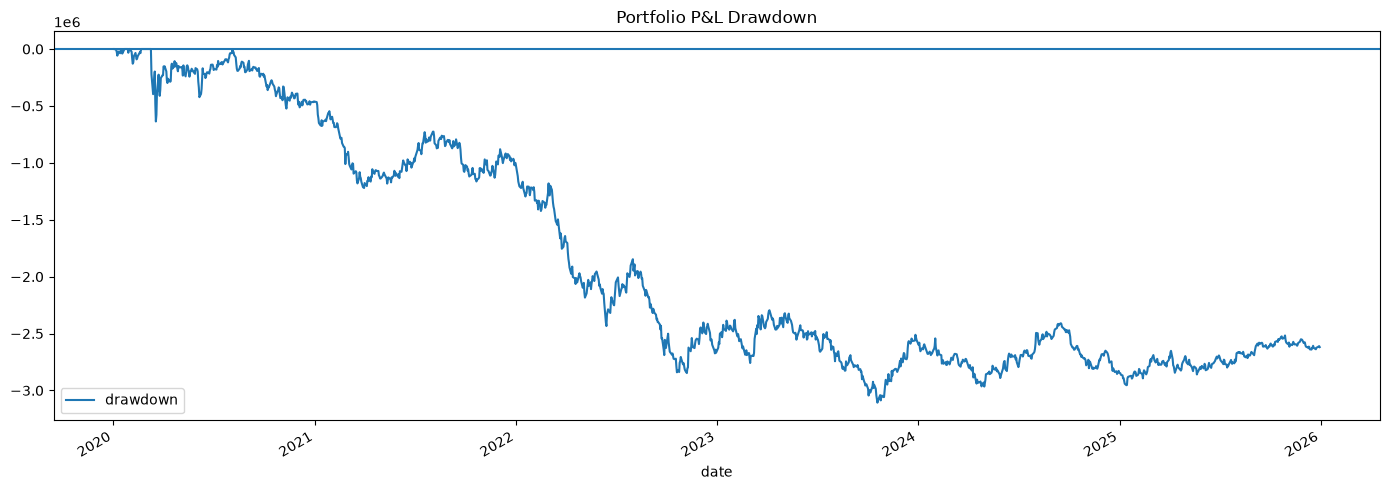

In [17]:
daily_pnl[
    "running_max"
] = daily_pnl[
    "cumulative_pnl"
].cummax()

daily_pnl[
    "drawdown"
] = (
    daily_pnl["cumulative_pnl"]
    - daily_pnl["running_max"]
)

daily_pnl.plot(
    x="date",
    y="drawdown",
    figsize=(14, 5),
    title="Portfolio P&L Drawdown",
)

plt.axhline(0)
plt.tight_layout()
plt.show()

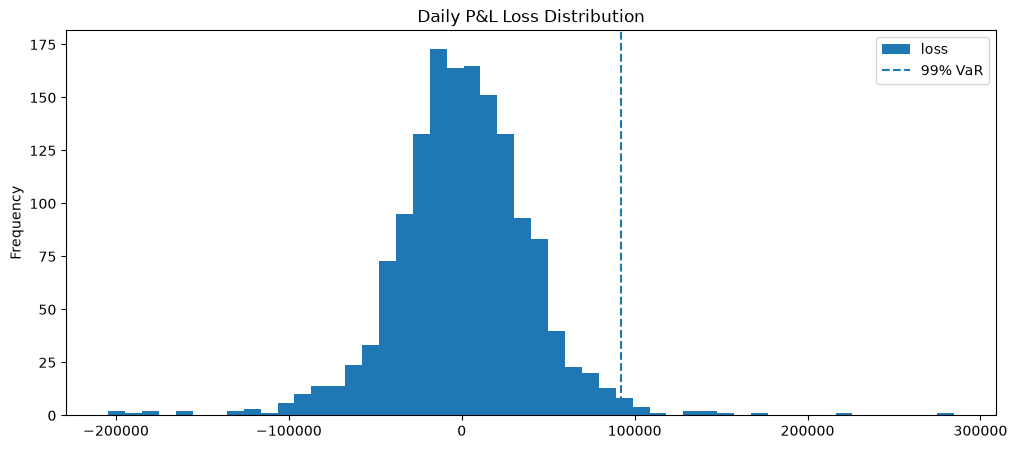

In [18]:
var_99 = metrics["var_99"]

daily_pnl["loss"] = (
    -daily_pnl["daily_pnl"]
)

daily_pnl["loss"].plot(
    kind="hist",
    bins=50,
    figsize=(12, 5),
    title="Daily P&L Loss Distribution",
)

plt.axvline(
    var_99,
    linestyle="--",
    label="99% VaR",
)

plt.legend()
plt.show()

In [19]:
from src.risk.stress_testing import run_stress_scenarios

stress_results = run_stress_scenarios()

stress_results

,scenario,description,base_portfolio_value,stress_pnl,stressed_value
0,Equity Down 10%,Broad equity market decline,5.233440e+06,-29439.758644,5.204001e+06
1,Equity Crash + Volatility Spike,Equity selloff accompanied by volatility increase,5.233440e+06,-44298.773656,5.189142e+06
2,Rates Up 100bp,Parallel upward rate shock,5.233440e+06,434787.922852,5.668228e+06
3,Rates Down 100bp,Parallel downward rate shock,5.233440e+06,-434787.922852,4.798652e+06
4,Combined Market Shock,"Equity decline, volatility increase and rates ...",5.233440e+06,375669.368917,5.609110e+06


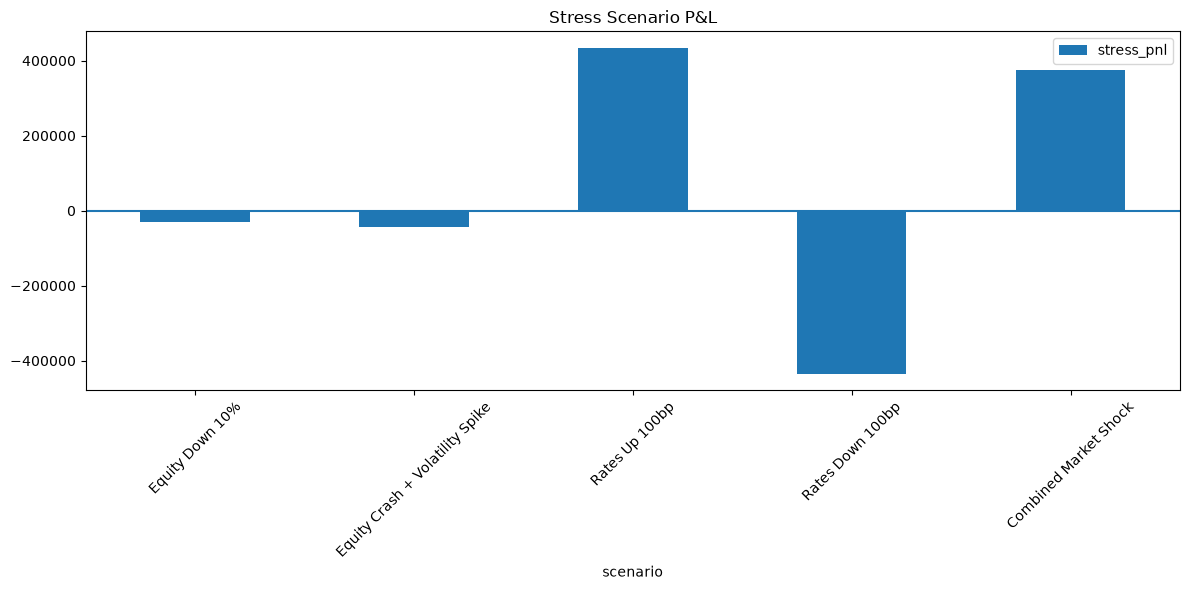

In [20]:
stress_results.plot(
    x="scenario",
    y="stress_pnl",
    kind="bar",
    figsize=(12, 6),
    title="Stress Scenario P&L",
)

plt.xticks(rotation=45)
plt.axhline(0)
plt.tight_layout()
plt.show()

In [21]:
summary = pd.DataFrame(
    {
        "Metric": [
            "VaR 99%",
            "Expected Shortfall 99%",
            "Worst Daily P&L",
            "Worst Stress P&L",
            "Limit Breaches",
            "Limit Warnings",
        ],
        "Value": [
            metrics["var_99"],
            metrics["es_99"],
            metrics["worst_daily_pnl"],
            metrics["worst_stress_pnl"],
            metrics["breaches"],
            metrics["warnings"],
        ],
    }
)

summary

,Metric,Value
0,VaR 99%,92151.254906
1,Expected Shortfall 99%,139652.442336
2,Worst Daily P&L,-284663.695095
3,Worst Stress P&L,-434787.922852
4,Limit Breaches,2.000000
5,Limit Warnings,2.000000


In [22]:
from src.risk.risk_commentary import (
    generate_commentary,
)

commentary = generate_commentary(
    var_99=metrics["var_99"],
    es_99=metrics["es_99"],
    worst_daily_pnl=metrics[
        "worst_daily_pnl"
    ],
    worst_stress_pnl=metrics[
        "worst_stress_pnl"
    ],
    breaches=metrics["breaches"],
    warnings=metrics["warnings"],
)

print(commentary)

99% historical VaR is 92,151.25. 99% Expected Shortfall is 139,652.44. The worst observed daily P&L was -284,663.70. The worst configured stress scenario produced P&L of -434,787.92. There are 2 active risk-limit breaches requiring attention.


In [23]:
commentary_file = (
    PROJECT_ROOT
    / "reports"
    / "risk_commentary.txt"
)

commentary_file.write_text(
    commentary,
    encoding="utf-8",
)

242